# Results

In [1]:
import os
import sys
ROOT = os.path.join(os.path.dirname(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(ROOT, 'src'))
from sen1floods11_dataset import Sen1Floods11Dataset, Sen1Floods11DataModule

/home/gahizon/.conda/envs/sar-env-SATLAS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/gahizon/.conda/envs/sar-env-SATLAS/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [79]:
DATA_PATH = os.path.join(ROOT, 'sen1floods11', 'hand_labeled.csv')
datamodule = Sen1Floods11DataModule(DATA_PATH, 'HandLabeled', target='Flood', batch_size=1, num_workers=4,
                              debug=False, transforms=[], in_channels=3, expand=1, filter_data=True, normalize=True)
datamodule.setup()
test_loader = datamodule.test_dataloader()[0]
holdout_loader = datamodule.test_dataloader()[1]


## Get Predictor Model

In [45]:
import torch
import segmentation_models_pytorch as smp
import wandb

def download_model(teacher):
        run = wandb.init()
        artifact = run.use_artifact(f'khizon/sar_seg_sen1floods11_A100/{teacher}', type='model')
        _ = artifact.download()
        wandb.finish()

def get_model(teacher):
        ROOT = os.getcwd()
        TEACHER_PATH = os.path.join(ROOT, 'artifacts', teacher, 'model.ckpt')
        if not os.path.exists(TEACHER_PATH):
            download_model(teacher)

        weights = torch.load(TEACHER_PATH)['state_dict']
        new_state_dict = {}
        for key, value in weights.items():
            new_key = key.replace("model.", "")
            new_state_dict[new_key] = value
        teacher_model = smp.UnetPlusPlus(
                    encoder_name= 'resnet50',
                    encoder_weights= None,
                    in_channels=3,
                    classes=1
                )
        # Load the state dictionary into the base model
        teacher_model.load_state_dict(new_state_dict)

        return teacher_model

In [ ]:
model = get_model('model-hiveajqa:v11')
model_2 = get_model('model-ahxsunm5:v11')

## Get Random Test Sample

In [148]:
import random

def get_random_sample(test_loader):
    num_batches = len(test_loader)
    # rand_batch_idx = random.randint(0, num_batches - 1)
    rand_batch_idx=2

    for i, batch in enumerate(test_loader):
        if i == rand_batch_idx:
            rand_batch = batch
            break

    img = rand_batch['img'].squeeze()
    label = rand_batch['label'].squeeze()

    return img, label

# img, label = get_random_sample(test_loader)
img, label = get_random_sample(holdout_loader)


## Test Model

In [149]:
with torch.no_grad():
    y_preds = model(img.unsqueeze(dim=0)).squeeze()
    y_preds_2 = model_2(img.unsqueeze(dim=0)).squeeze()

In [150]:
from torchmetrics import JaccardIndex

metric = JaccardIndex(task='BINARY', num_classes=2, ignore_index=-1)

mIoU = metric(y_preds, label)*100
mIoU_2 = metric(y_preds_2, label)*100

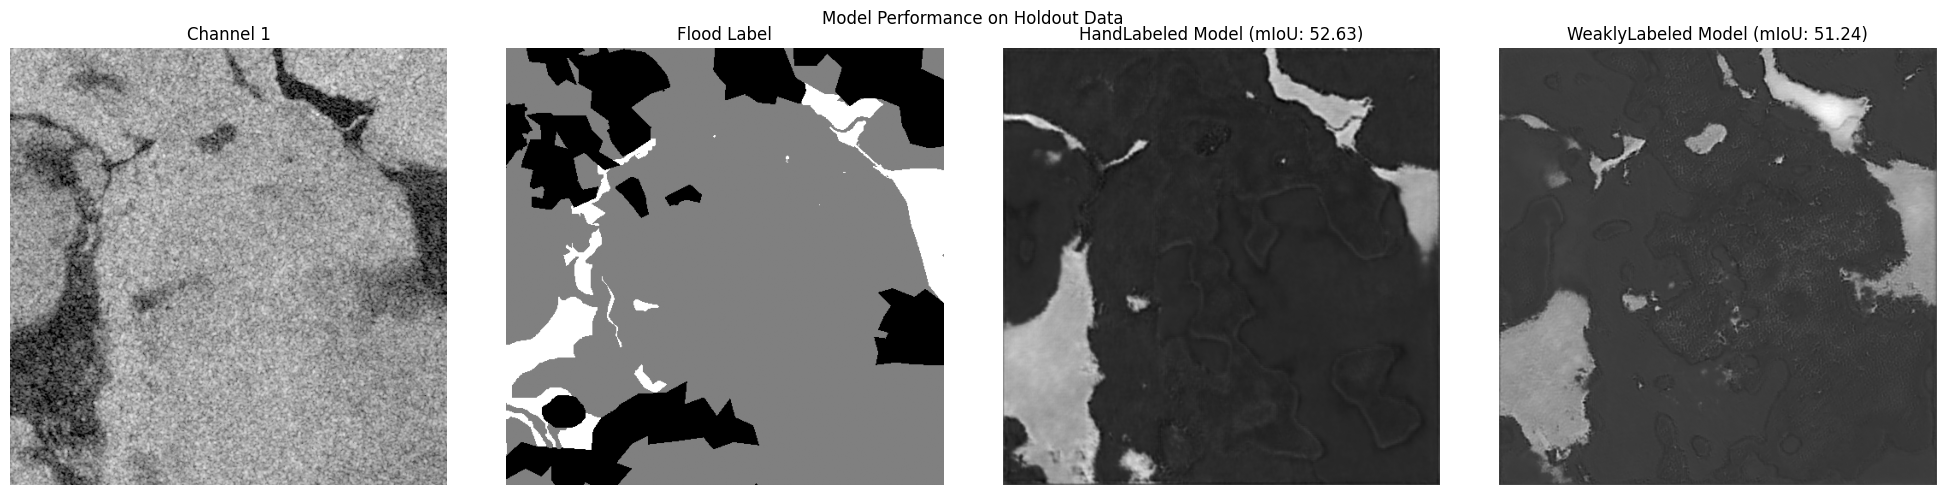

In [151]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# Channel 1
axs[0].imshow(img[1].cpu(), cmap='gray')
axs[0].set_title("Channel 1")
axs[0].axis("off")

# Label
axs[1].imshow(label.cpu(), cmap='gray')
axs[1].set_title("Flood Label")
axs[1].axis("off")

# Label
axs[2].imshow(y_preds.cpu(), cmap='gray')
axs[2].set_title(f"HandLabeled Model (mIoU: {mIoU:.2f})")
axs[2].axis("off")

# Label
axs[3].imshow(y_preds_2.cpu(), cmap='gray')
axs[3].set_title(f"WeaklyLabeled Model (mIoU: {mIoU_2:.2f})")
axs[3].axis("off")

plt.suptitle("Model Performance on Holdout Data")
plt.tight_layout()
plt.show()